Style Loaded

METRICS:
MAE: 17.97189467382933
MSE: 480.89960161442383
RMSE: 21.929423193837632
R2: 0.9660685782996334
AdjR2: 0.962926779994044

✅ MODEL SAVED AS: linear_regression_model.pkl


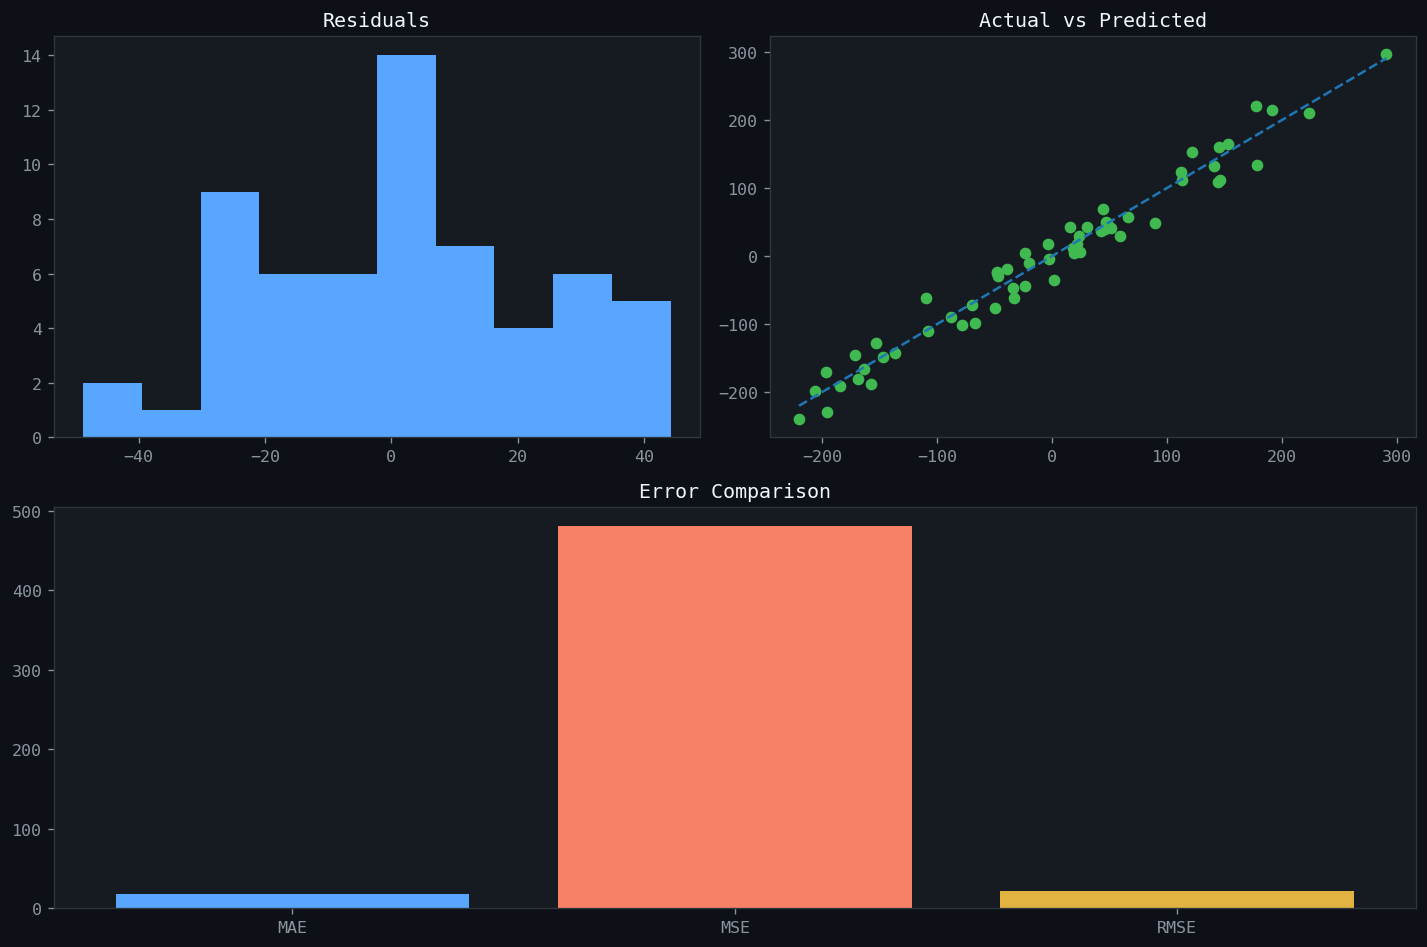


GD DONE
Final cost: 8.633251274434104e+155
w: -3.8076263302291925e+77 b: -5.725153915535644e+76
✅ GD MODEL SAVED AS: gd_model.pkl


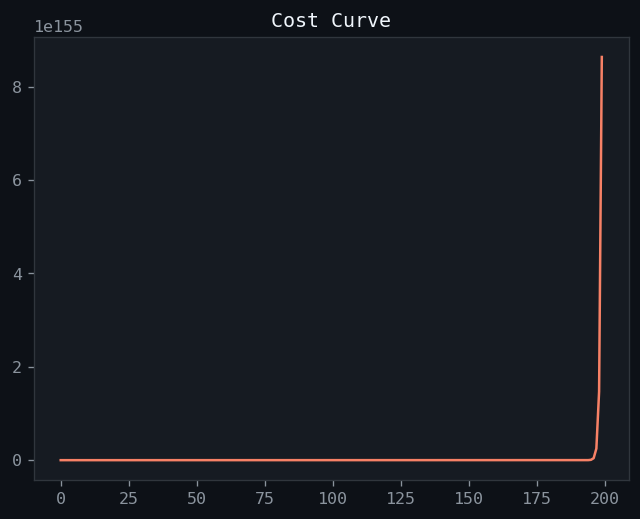

✅ Animation saved: gd_animation.gif

🎯 PROJECT COMPLETED SUCCESSFULLY


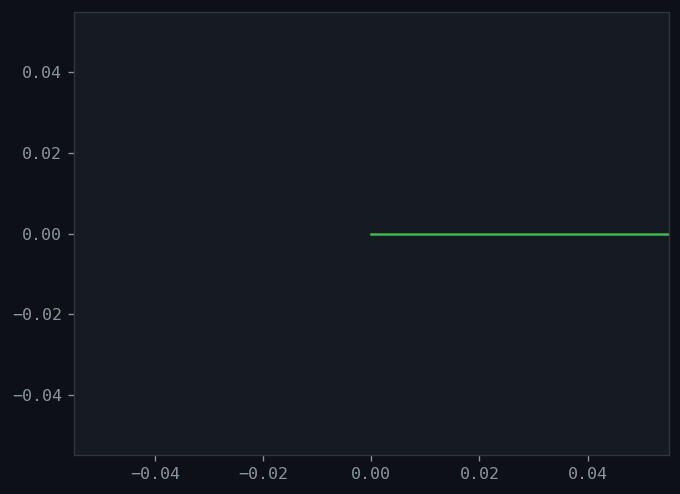

In [5]:
# ============================================================
#  REGRESSION METRICS + GD + MODEL SAVE (PKL)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pickle
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# STYLE
# ─────────────────────────────────────────────
DARK_BG = "#0d1117"
ACCENT1 = "#58a6ff"
ACCENT2 = "#3fb950"
ACCENT3 = "#f78166"
GOLD    = "#e3b341"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": "#161b22",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "font.family": "monospace",
    "figure.dpi": 120
})

print("Style Loaded")

# ─────────────────────────────────────────────
# DATA
# ─────────────────────────────────────────────
np.random.seed(42)

X, y = make_regression(n_samples=300, n_features=5, noise=25)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ─────────────────────────────────────────────
# MODEL TRAIN
# ─────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ─────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]
AdjR2 = 1 - (1 - R2) * (n - 1) / (n - p - 1)

print("\nMETRICS:")
print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)
print("R2:", R2)
print("AdjR2:", AdjR2)

# ─────────────────────────────────────────────
# SAVE MODEL AS PKL ⭐ IMPORTANT ADDITION
# ─────────────────────────────────────────────
model_filename = "linear_regression_model.pkl"

with open(model_filename, "wb") as file:
    pickle.dump(model, file)

print("\n✅ MODEL SAVED AS:", model_filename)

# ─────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(y_test - y_pred, color=ACCENT1)
ax1.set_title("Residuals")

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_test, y_pred, color=ACCENT2)
ax2.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--')
ax2.set_title("Actual vs Predicted")

ax3 = fig.add_subplot(gs[1, :])
ax3.bar(["MAE", "MSE", "RMSE"], [MAE, MSE, RMSE],
        color=[ACCENT1, ACCENT3, GOLD])
ax3.set_title("Error Comparison")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# GRADIENT DESCENT
# ─────────────────────────────────────────────
class GD:
    def __init__(self, lr=0.05, n_iter=200):
        self.lr = lr
        self.n_iter = n_iter
        self.w = 0
        self.b = 0
        self.cost = []

    def fit(self, x, y):
        for _ in range(self.n_iter):
            yhat = self.w * x + self.b
            err = yhat - y
            self.w -= self.lr * np.mean(2 * err * x)
            self.b -= self.lr * np.mean(2 * err)
            self.cost.append(np.mean(err**2))
        return self

# 1D data
x = np.linspace(0, 10, 100)
y_gd = 3.5 * x + 7 + np.random.normal(0, 8, 100)

gd = GD()
gd.fit(x, y_gd)

print("\nGD DONE")
print("Final cost:", gd.cost[-1])
print("w:", gd.w, "b:", gd.b)

# ─────────────────────────────────────────────
# SAVE GD MODEL TOO (OPTIONAL)
# ─────────────────────────────────────────────
gd_model = {
    "w": gd.w,
    "b": gd.b,
    "cost": gd.cost
}

with open("gd_model.pkl", "wb") as f:
    pickle.dump(gd_model, f)

print("✅ GD MODEL SAVED AS: gd_model.pkl")

# ─────────────────────────────────────────────
# COST PLOT
# ─────────────────────────────────────────────
plt.figure()
plt.plot(gd.cost, color=ACCENT3)
plt.title("Cost Curve")
plt.show()

# ─────────────────────────────────────────────
# ANIMATION SAVE
# ─────────────────────────────────────────────
fig, ax = plt.subplots()
x_line = np.linspace(min(x), max(x), 100)
line, = ax.plot([], [], color=ACCENT2)

def update(i):
    w = gd.w * (i / len(gd.cost))
    b = gd.b * (i / len(gd.cost))
    line.set_data(x_line, w * x_line + b)
    return line,

ani = animation.FuncAnimation(fig, update, frames=50)
ani.save("gd_animation.gif", writer="pillow", fps=10)

print("✅ Animation saved: gd_animation.gif")

# ─────────────────────────────────────────────
# END
# ─────────────────────────────────────────────
print("\n🎯 PROJECT COMPLETED SUCCESSFULLY")